In [1]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
#load the data set
# Load dataset
df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")

df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [5]:
# Select Required Columns
# We only keep useful columns

df = df[['Name','Year','Genre','Director','Actor 1','Actor 2','Actor 3','Rating','Votes']]

df.head()

,Name,Year,Genre,Director,Actor 1,Actor 2,Actor 3,Rating,Votes
0,,NaN,Drama,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia,NaN,NaN
1,#Gadhvi (He thought he was Gandhi),(2019),Drama,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,7.0,8
2,#Homecoming,(2021),"Drama, Musical",Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana,NaN,NaN
3,#Yaaram,(2019),"Comedy, Romance",Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,4.4,35
4,...And Once Again,(2010),Drama,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali,NaN,NaN


In [6]:
# Data Cleaning 

# Remove missing values

df = df.dropna()

df.shape

(7558, 9)

In [7]:
# Convert rating & votes

df['Rating'] = df['Rating'].astype(float)

df['Votes'] = df['Votes'].str.replace(',', '')
df['Votes'] = df['Votes'].astype(float)


In [8]:
# Year Cleaning

df['Year'] = df['Year'].str.replace('(', '')
df['Year'] = df['Year'].str.replace(')', '')
df['Year'] = df['Year'].astype(int)

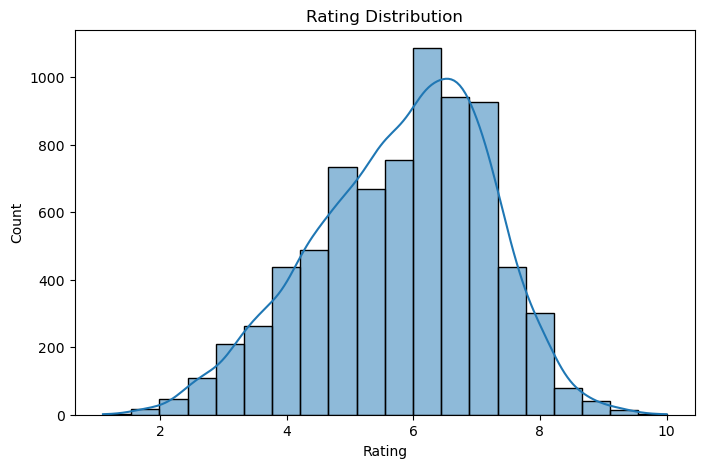

In [9]:
# Visualization
# Rating Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title("Rating Distribution")
plt.show()

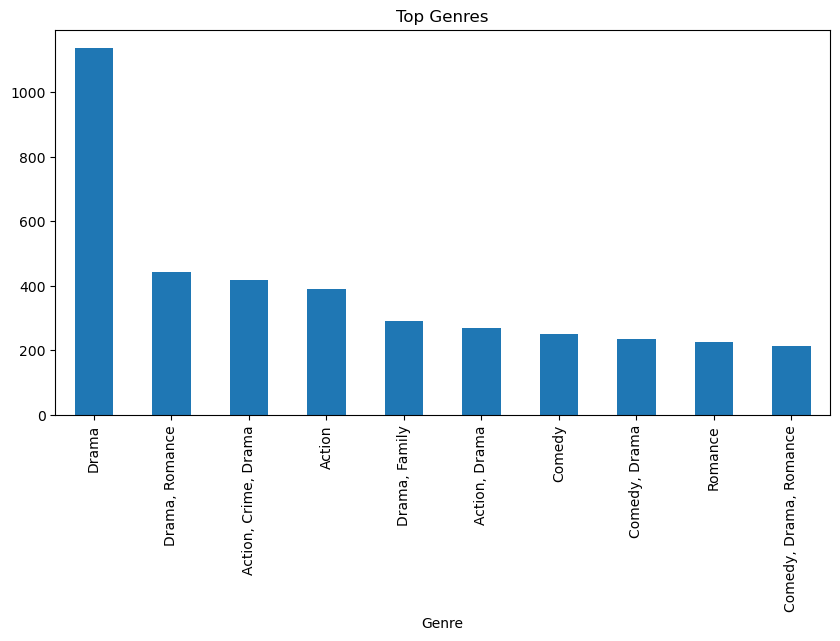

In [10]:
# top genres
plt.figure(figsize=(10,5))

df['Genre'].value_counts().head(10).plot(kind='bar')

plt.title("Top Genres")
plt.show()

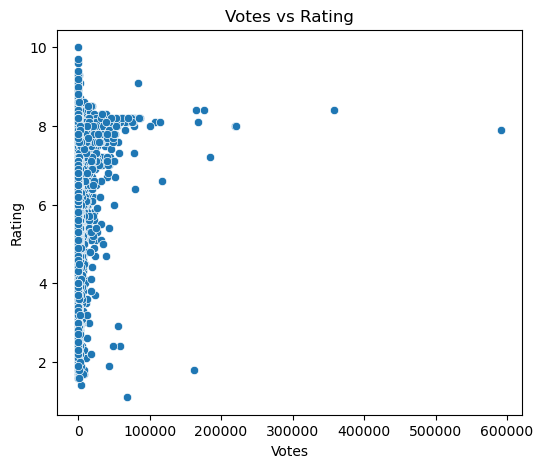

In [11]:
# Votes vs Rating

plt.figure(figsize=(6,5))

sns.scatterplot(x=df['Votes'], y=df['Rating'])

plt.title("Votes vs Rating")
plt.show()

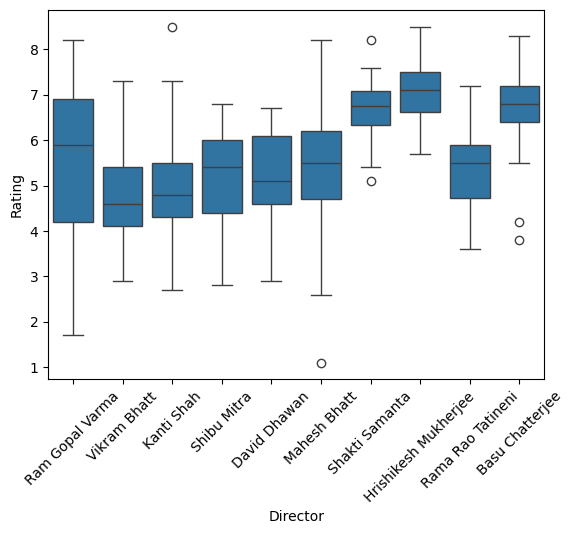

In [12]:
# Director vs Rating

top_director = df['Director'].value_counts().head(10).index

sns.boxplot(
    x=df[df['Director'].isin(top_director)]['Director'],
    y=df[df['Director'].isin(top_director)]['Rating']
)

plt.xticks(rotation=45)
plt.show()

In [13]:
# Feature Encoding
le_genre = LabelEncoder()
le_dir = LabelEncoder()
le_a1 = LabelEncoder()
le_a2 = LabelEncoder()
le_a3 = LabelEncoder()

df['Genre'] = le_genre.fit_transform(df['Genre'])
df['Director'] = le_dir.fit_transform(df['Director'])
df['Actor 1'] = le_a1.fit_transform(df['Actor 1'])
df['Actor 2'] = le_a2.fit_transform(df['Actor 2'])
df['Actor 3'] = le_a3.fit_transform(df['Actor 3'])

In [14]:
# Features & Target

X = df[['Genre','Director','Actor 1','Actor 2','Actor 3','Year','Votes']]
y = df['Rating']

In [15]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [16]:
# Train Regression Model
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestRegressor(max_depth=12, n_estimators=200, random_state=42)

In [21]:
# Prediction

pred = model.predict(X_test)

In [22]:
# Evaluation
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 0.8498148660317819
R2 Score: 0.32716332393933245


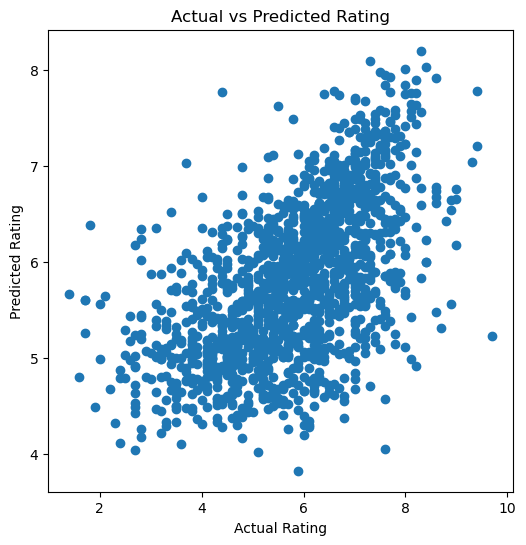

In [23]:
# Visualization of Prediction

plt.figure(figsize=(6,6))

plt.scatter(y_test, pred)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")

plt.title("Actual vs Predicted Rating")

plt.show()

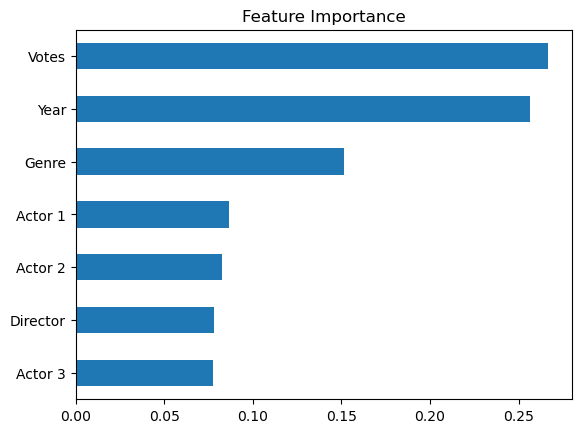

In [24]:
# Feature Importance

imp = pd.Series(model.feature_importances_, index=X.columns)

imp.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

In [25]:
# Save the model 

import pickle

save_data = {
    "model": model,
    "le_genre": le_genre,
    "le_dir": le_dir,
    "le_a1": le_a1,
    "le_a2": le_a2,
    "le_a3": le_a3,
    "features": ['Genre','Director','Actor 1','Actor 2','Actor 3','Year','Votes']
}

with open("movie_rating_model.pkl", "wb") as f:
    pickle.dump(save_data, f)

print("Saved in one file")


Saved in one file
